In [1]:
import os
import sys
from pathlib import Path

import torch
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

torch.manual_seed(8008135)

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print("CODE_DIR:", CODE_DIR)
print("CODE_DIR contents:", os.listdir(CODE_DIR))

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

CODE_DIR: /home/daniel/HRM_Reconstruction/code
CODE_DIR contents: ['GPT2_Model', 'Utils', 'HRM_Model', 'Datasets', '.DS_Store', 'BiLSTM_Model', 'Sudoku', 'BERT_Model']
Device set to cuda


In [2]:
from Sudoku.sudoku import print_sudoku_comparison

from Datasets.Sudoku_DataLoader import get_loaders

from GPT2_Model.GPT2_Sudoku import GPT2_Baseline, GPT2Config
from GPT2_Model.GPT2_Train import train_gpt2

from Utils.schedules import cosine_schedule_with_warmup_lr_lambda
from Utils.checkpointing import load_checkpoint
from Utils.visualization import show_sudoku_predictions

/home/daniel/anaconda3/envs/HRM/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_size = 2**13
test_size = 2**8
batch_size = 2**8

train_loader, val_loader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

Map: 100%|██████████| 256/256 [00:00<00:00, 28679.00 examples/s]


In [4]:
model_config = GPT2Config(
    num_layers=12,
    num_heads=8,
    embedding_dim=512,
    vocab_size=10,
    block_size=81,
    dropout=0.2
)

lr = 1e-4
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 10

checkpoint_dir = "checkpoints"

In [5]:
model = GPT2_Baseline(model_config).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)

Number of trainable parameters: 37,881,344


In [6]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    betas=(beta1, beta2),
    weight_decay=weight_decay,
)

num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(0.05 * num_training_steps)

scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_schedule_with_warmup_lr_lambda(
        step,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
        min_ratio=0.1,
    ),
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

num_training_steps: 320
num_warmup_steps: 16


In [7]:
model, best_metric, history = train_gpt2(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    device=device,
    scheduler=scheduler,
    num_epochs=num_epochs,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=5,
    validate_every=5,
    val_loader=val_loader,
    step_val_batches=1,
)

model.eval()

print("Best board accuracy used for checkpointing:", best_metric)

Number of trainable parameters: 37,881,344


Epoch 1: 100%|██████████| 32/32 [00:07<00:00,  4.57it/s]


Epoch 1: Avg Train Loss = 2.2426, Train Token Accuracy = 11.19%, Train Board Accuracy = 0.00%, LR = 9.94e-05


Epoch 2: 100%|██████████| 32/32 [00:06<00:00,  4.71it/s]


Epoch 2: Avg Train Loss = 2.1939, Train Token Accuracy = 12.08%, Train Board Accuracy = 0.00%, LR = 9.46e-05


...

Epoch 9: Avg Train Loss = 2.0398, Train Token Accuracy = 14.86%, Train Board Accuracy = 0.00%, LR = 1.24e-05


Epoch 10: 100%|██████████| 32/32 [00:06<00:00,  4.73it/s]


Epoch 10: Avg Train Loss = 2.0353, Train Token Accuracy = 15.07%, Train Board Accuracy = 0.00%, LR = 1.00e-05


Validation: 100%|██████████| 1/1 [00:00<00:00, 13.92it/s]


Val Loss = 2.0194, Val Token Accuracy = 16.82%, Val Board Accuracy = 0.00%

Best board accuracy used for checkpointing: 0.0


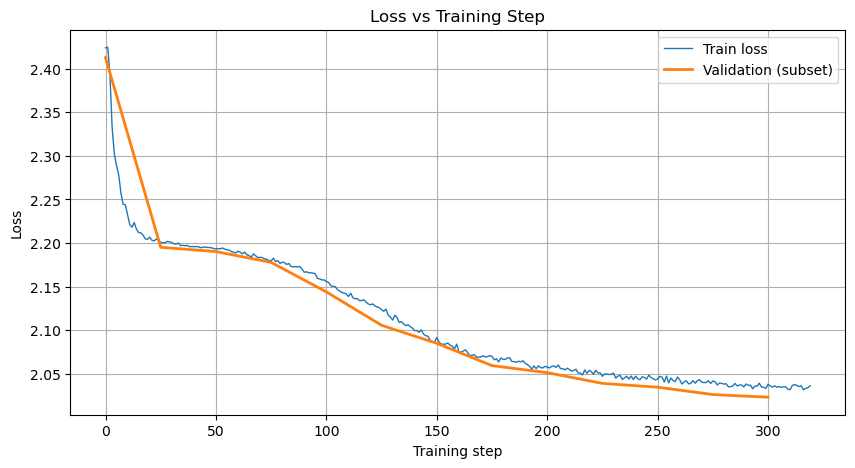

In [12]:
import matplotlib.pyplot as plt

train_steps = history["step"]
train_loss = history["train_loss"]

val_steps = [
    s for s, v in zip(history["step"], history["val_loss"])
    if v is not None
]

val_loss = [
    v for v in history["val_loss"]
    if v is not None
]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train loss", linewidth=1)

if len(val_loss) > 0:
    plt.plot(val_steps, val_loss, label="Validation (subset)", linewidth=2)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Loss vs Training Step")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
show_sudoku_predictions(
    model,
    val_loader,
    device,
    print_sudoku_comparison,
    num_examples=10,
)

Input / Prediction
6 9 5 | 3 3 1 | 2 3 5 
4 3 5 | 9 2 8 | 4 9 6 
1 6 8 | 3 3 3 | 3 8 3 
---------------------------------
9 7 3 | 9 6 9 | 1 4 9 
6 2 6 | 7 5 7 | 7 9 9 
1 6 3 | 7 2 7 | 2 7 2 
---------------------------------
6 1 2 | 9 3 6 | 2 2 5 
5 5 9 | 7 1 5 | 1 1 9 
9 8 7 | 2 1 6 | 1 1 4 

Unknown-cell token accuracy: 0.18518517911434174

Input / Prediction
6 9 5 | 3 3 3 | 5 6 3 
4 1 5 | 9 8 9 | 9 1 1 
1 6 8 | 7 9 3 | 2 9 9 
---------------------------------
9 9 4 | 3 6 5 | 8 9 8 
5 9 6 | 4 4 4 | 6 3 4 
9 9 6 | 4 4 9 | 4 5 4 
---------------------------------
3 8 5 | 9 1 4 | 9 9 4 
1 5 9 | 8 8 7 | 8 2 9 
5 2 3 | 9 1 1 | 1 7 1 

Unknown-cell token accuracy: 0.1666666716337204

Input / Prediction
6 1 4 | 9 9 8 | 2 2 1 
9 6 1 | 9 1 1 | 2 1 1 
1 4 8 | 5 2 6 | 9 6 6 
---------------------------------
4 9 6 | 6 9 1 | 1 9 8 
8 9 6 | 4 4 5 | 8 6 6 
1 6 6 | 9 9 2 | 4 6 5 
---------------------------------
9 4 8 | 1 8 4 | 4 7 4 
5 4 9 | 9 9 9 | 9 3 9 
3 5 9 | 2 9 9 | 6 9 9 

Unknown-cell tok

In [10]:
torch.save(
    model.state_dict(),
    "checkpoints/gpt2_final_state_dict.pt",
)